In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    RBF,
    Matern,
    RationalQuadratic,
    WhiteKernel,
)
from sklearn.base import clone

from sklearn.metrics import mean_squared_error, r2_score

# SETTINGS
warnings.filterwarnings("ignore")

RANDOM_STATE = 4
KNN_NEIGHBORS = 5

In [2]:
df = pd.read_csv("../data/Data.csv")
print(f"Loaded shape: {df.shape}")

df.sample(10, random_state=RANDOM_STATE)

Loaded shape: (374, 8)


,MOF,Surface area (m2/g),Pore Volume (cm3/g),Catalyst dosage (g/L),Antibiotic dosage (mg/L),Illumination time (min),pH,Degradation (%)
172,MIL-101,252.59,0.860,0.50,30,40,8.00,56.6
319,MIL-100-PANI,950.00,0.300,0.25,10,15,3.00,10.7
336,MIL-100-PANI,950.00,0.300,0.25,10,120,5.00,18.7
14,MIL-101,180.41,0.320,0.15,50,20,4.10,83.0
202,PI-UiO-66-NH2,922.75,0.500,0.20,10,10,9.00,19.0
61,MIL-88A,15.95,0.110,0.50,200,20,3.45,46.1
317,MIL-100-PANI,950.00,0.300,0.25,10,135,2.00,100.0
128,MIL-88A,15.95,0.110,0.25,200,20,9.00,27.6
225,In2S3-MIL-125-Ti,303.90,0.464,0.30,46,60,5.90,64.1
281,AgI-UiO-66-NH2,425.88,0.273,0.30,10,0,5.50,9.8


In [3]:
buffer_info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
})

buffer_info

,dtype,n_unique,n_missing
MOF,object,10,0
Surface area (m2/g),float64,13,0
Pore Volume (cm3/g),float64,13,0
Catalyst dosage (g/L),float64,12,0
Antibiotic dosage (mg/L),int64,7,0
Illumination time (min),int64,25,0
pH,float64,18,0
Degradation (%),float64,302,0


In [4]:
# Duplicate analysis
n_exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact_duplicates}")

if n_exact_duplicates > 0:
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

Exact duplicate rows: 0


In [5]:
X = df.drop(["Degradation (%)","MOF"], axis=1)
y = df["Degradation (%)"]

feature_names = X.columns.tolist()
n_features = len(feature_names)

In [6]:
def compute_univariate_stats(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Compute descriptive statistics (min, max, mean, median, std, IQR, skew, n_unique)."""
    rows = []
    for col in cols:
        series = pd.to_numeric(df[col], errors="coerce").dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        rows.append({
            "Variable": col,
            "Min": series.min(),
            "Max": series.max(),
            "Mean": series.mean(),
            "Median": series.median(),
            "Std": series.std(),
            "Q1": q1,
            "Q3": q3,
            "IQR": q3 - q1,
            "Skewness": stats.skew(series),
            "N Unique": series.nunique(),
            "N Obs": series.shape[0],
        })

    stats_df = pd.DataFrame(rows).set_index("Variable").round(3)
    return stats_df

# Execute Phase
univariate_stats = compute_univariate_stats(df, X)
print("UNIVARIATE DESCRIPTIVE STATISTICS")
display(univariate_stats)

UNIVARIATE DESCRIPTIVE STATISTICS


,Min,Max,Mean,Median,Std,Q1,Q3,IQR,Skewness,N Unique,N Obs
Variable,,,,,,,,,,,
Surface area (m2/g),15.95,1548.30,374.222,252.59,351.250,180.41,425.88,245.47,1.177,13,374
Pore Volume (cm3/g),0.11,0.86,0.353,0.30,0.247,0.20,0.32,0.12,1.190,13,374
Catalyst dosage (g/L),0.05,2.00,0.412,0.30,0.409,0.25,0.50,0.25,2.656,12,374
Antibiotic dosage (mg/L),10.00,200.00,66.588,40.00,74.552,10.00,50.00,40.00,1.142,7,374
Illumination time (min),0.00,360.00,43.810,30.00,46.320,10.00,60.00,50.00,2.260,25,374
pH,1.00,12.20,5.871,5.50,2.489,4.10,8.00,3.90,0.078,18,374


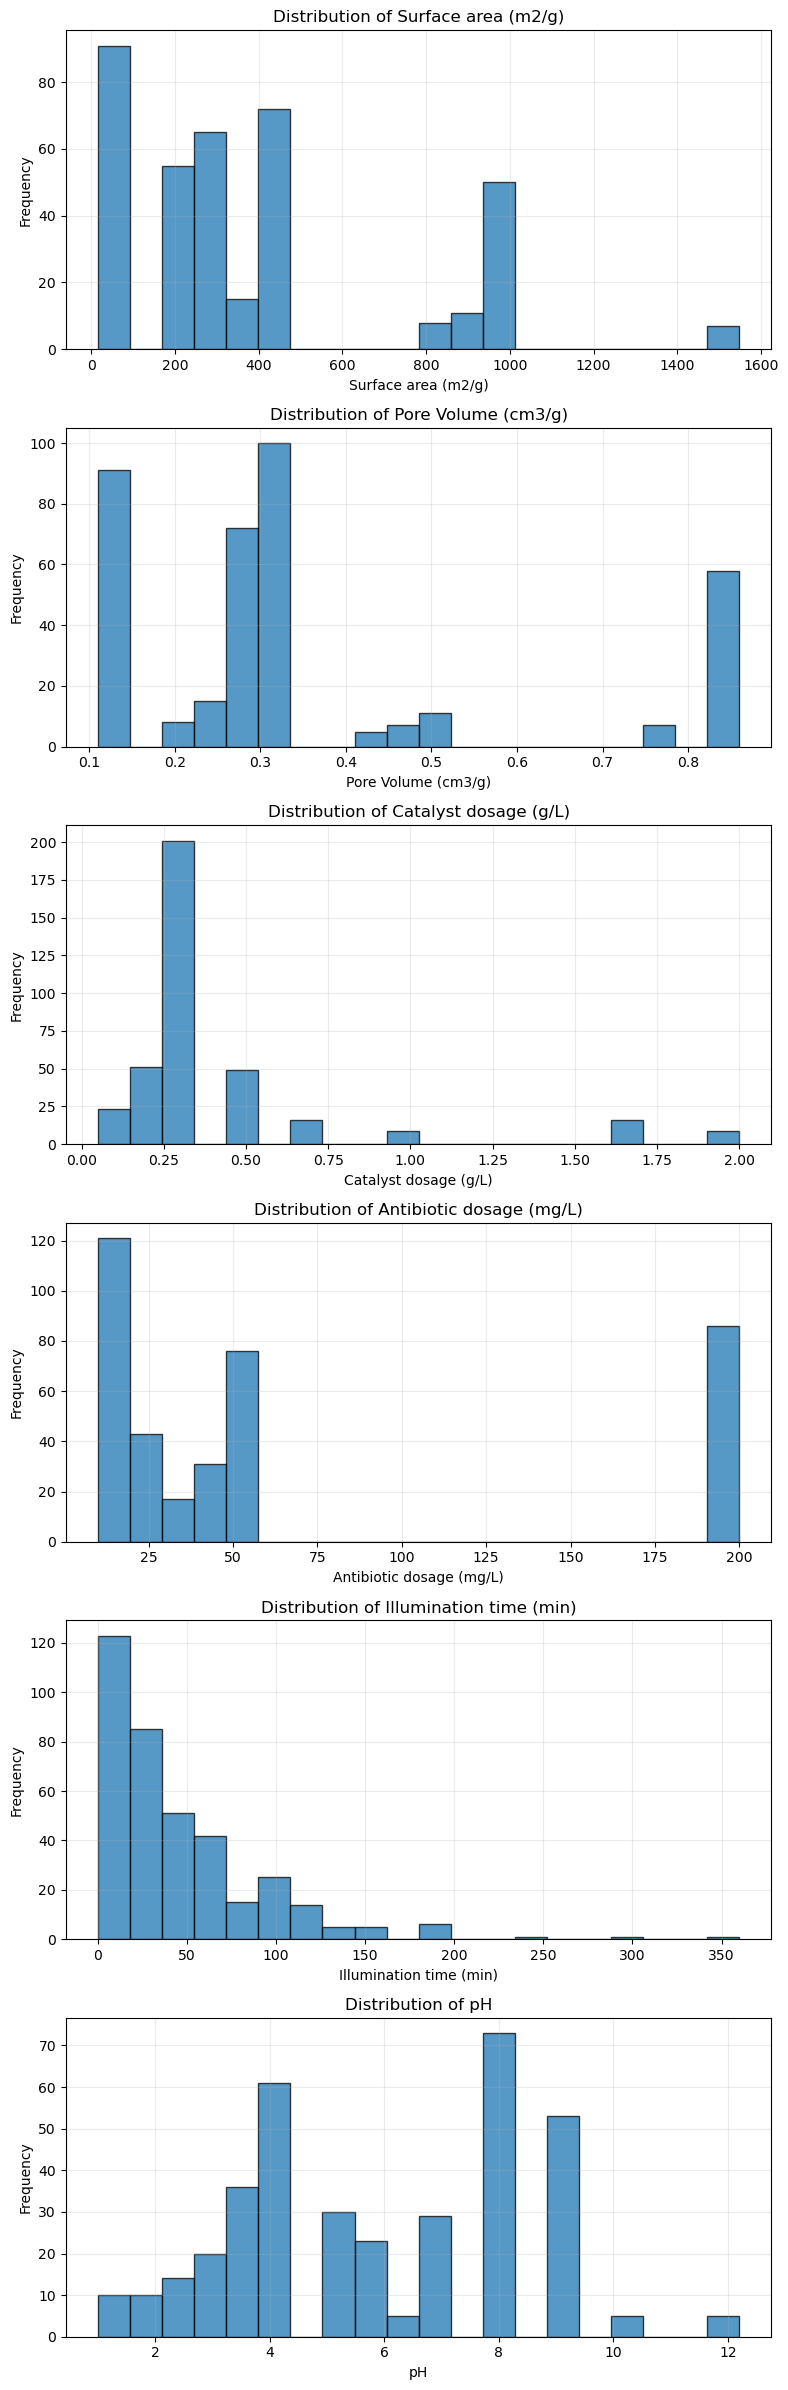

In [7]:
# Plot the distribution of each input feature

fig, axes = plt.subplots(
    nrows=n_features,
    ncols=1,
    figsize=(8, 4 * n_features)
)

# Ensure axes is iterable when there is only one feature
if n_features == 1:
    axes = [axes]

for ax, feature in zip(axes, feature_names):

    values = X[feature]
    # Plot histogram
    ax.hist(
        values,
        bins=20,
        edgecolor="black",
        alpha=0.75
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

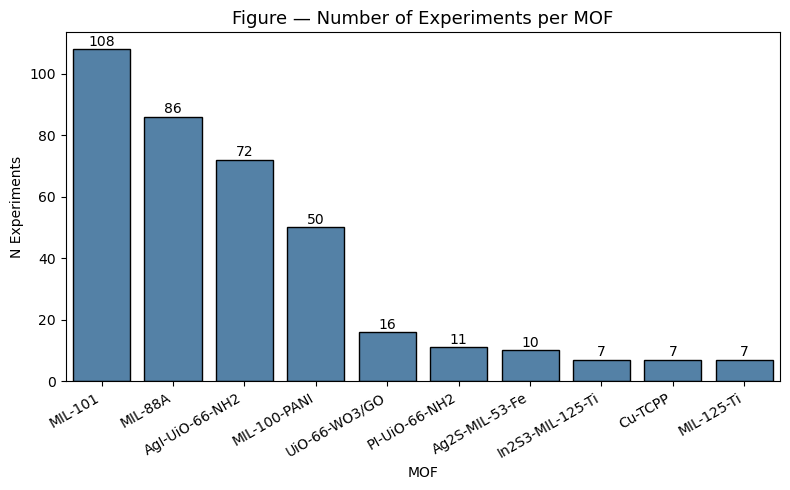

In [8]:
# Analyze MOFs (Categorical)
def plot_categorical_distribution(
    df: pd.DataFrame,
    col: str,
    order: list[str] | None = None,
    annotate: bool = True,
) -> None:
    """Bar plot of counts per category, ordered by frequency."""
    counts = df[col].value_counts()
    if order is None:
        order = counts.index.tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        x=counts.loc[order].index,
        y=counts.loc[order].values,
        order=order,
        color="steelblue",
        edgecolor="black",
        ax=ax,
    )

    if annotate:
        for i, val in enumerate(counts.loc[order].values):
            ax.text(i, val + counts.max() * 0.01, str(val), ha="center", fontsize=10)

    ax.set_title(f"Figure — Number of Experiments per {col}", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("N Experiments")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Execute
plot_categorical_distribution(df, "MOF")

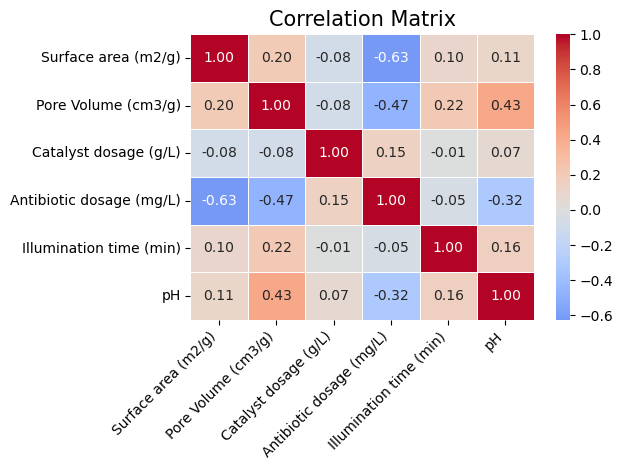

In [9]:
# CORRELATION MATRIX
corr_matrix = X.corr()

plt.figure()

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# VIF CHECK

X_vif = X

# Add intercept
X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

# Remove intercept from results
vif_data = vif_data[vif_data["Variable"] != "const"]

# Sort highest to lowest
vif_data = (
    vif_data
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

display(vif_data.round(3))

,Variable,VIF
0,Antibiotic dosage (mg/L),2.189
1,Surface area (m2/g),1.716
2,Pore Volume (cm3/g),1.517
3,pH,1.290
4,Illumination time (min),1.082
5,Catalyst dosage (g/L),1.041


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [12]:
# GPR KERNELS

kernels = {

    # Matern kernel
    "GPR Matern": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3)
        )
        *
        Matern(
            length_scale=1.0,
            length_scale_bounds=(1e-3, 1e3),
            nu=1.5
        )
        +
        WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)
        )
    ),

    # Exponential kernel = Matern nu = 0.5
    "GPR Exp": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3)
        )
        *
        Matern(
            length_scale=1.0,
            length_scale_bounds=(1e-3, 1e3),
            nu=0.5
        )
        +
        WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)
        )
    ),

    # Squared exponential kernel
    "GPR SExp": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3)
        )
        *
        RBF(
            length_scale=1.0,
            length_scale_bounds=(1e-3, 1e3)
        )
        +
        WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)
        )
    ),

    # Rational quadratic kernel
    "GPR Rational Quadratic": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3)
        )
        *
        RationalQuadratic(
            length_scale=1.0,
            alpha=1.0,
            length_scale_bounds=(1e-3, 1e3),
            alpha_bounds=(1e-3, 1e3)
        )
        +
        WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)
        )
    ),
}

In [13]:
# BUILD GPR PIPELINE

def make_gpr_model(kernel):

    steps = []


    steps.append(
        ("scaler", StandardScaler())
    )

    steps.append(
        (
            "gpr",
            GaussianProcessRegressor(
                kernel=clone(kernel),

                # Noise is already represented by WhiteKernel
                alpha=0.0,

                normalize_y=True,

                n_restarts_optimizer=15,

                random_state=RANDOM_STATE
            )
        )
    )

    return Pipeline(steps)

In [14]:
# PERFORMANCE METRICS
def regression_metrics(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    residuals = y_true - y_pred

    r2 = r2_score(y_true, y_pred)

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    # Mean Relative Error
    denominator = np.where(
        np.abs(y_true) < 1e-12,
        np.nan,
        np.abs(y_true)
    )

    mre = np.nanmean(
        np.abs(y_pred - y_true) / denominator
    ) * 100

    # Standard deviation of residual errors
    std = np.std(
        residuals,
        ddof=0
    )

    return {
        "R²": r2,
        "MRE (%)": mre,
        "MSE": mse,
        "RMSE": rmse,
        "STD": std,
    }

In [15]:
# Fit GPR Models

fitted_models = {}
results = []

for model_name, kernel in kernels.items():

    model = make_gpr_model(kernel)

    # Train
    model.fit(
        X_train,
        y_train
    )

    fitted_models[model_name] = model

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_total_pred = model.predict(X)

    # Metrics
    train_metrics = regression_metrics(
        y_train,
        y_train_pred
    )

    test_metrics = regression_metrics(
        y_test,
        y_test_pred
    )

    total_metrics = regression_metrics(
        y,
        y_total_pred
    )

    for dataset_name, metrics in [
        ("Train", train_metrics),
        ("Test", test_metrics),
        ("Total", total_metrics)
    ]:

        results.append({
            "Model": model_name,
            "Dataset": dataset_name,
            **metrics
        })

    # Show optimized kernel

    optimized_kernel = (
        model
        .named_steps["gpr"]
        .kernel_
    )

In [16]:
# RESULTS TABLE
gpr_results = pd.DataFrame(results)

for col in [
    "R²",
    "MRE (%)",
    "MSE",
    "RMSE",
    "STD"
]:
    gpr_results[col] = gpr_results[col].astype(float)


table_1_df = (
    gpr_results
    .set_index(["Model", "Dataset"])
    .round({
        "R²": 3,
        "MRE (%)": 2,
        "MSE": 2,
        "RMSE": 2,
        "STD": 2
    })
)

print(
    "\nStatistical Parameters "
    "of Suggested GPR Models"
)

display(table_1_df)


Statistical Parameters of Suggested GPR Models


R²  MRE (%)     MSE   RMSE    STD
Model                  Dataset                                      
GPR Matern             Train    0.987     7.60   10.51   3.24   3.24
                       Test     0.876    57.38  109.86  10.48  10.19
                       Total    0.964    17.59   30.44   5.52   5.49
GPR Exp                Train    1.000     0.31    0.02   0.13   0.13
                       Test     0.851    60.80  132.62  11.52  11.13
                       Total    0.969    12.44   26.61   5.16   5.12
GPR SExp               Train    0.981    10.89   16.22   4.03   4.03
                       Test     0.877    59.02  109.67  10.47  10.27
                       Total    0.959    20.54   34.96   5.91   5.90
GPR Rational Quadratic Train    0.984     8.91   13.66   3.70   3.70
                       Test     0.882    57.52  105.11  10.25  10.02
                       Total    0.962    18.66   32.00   5.66   5.64

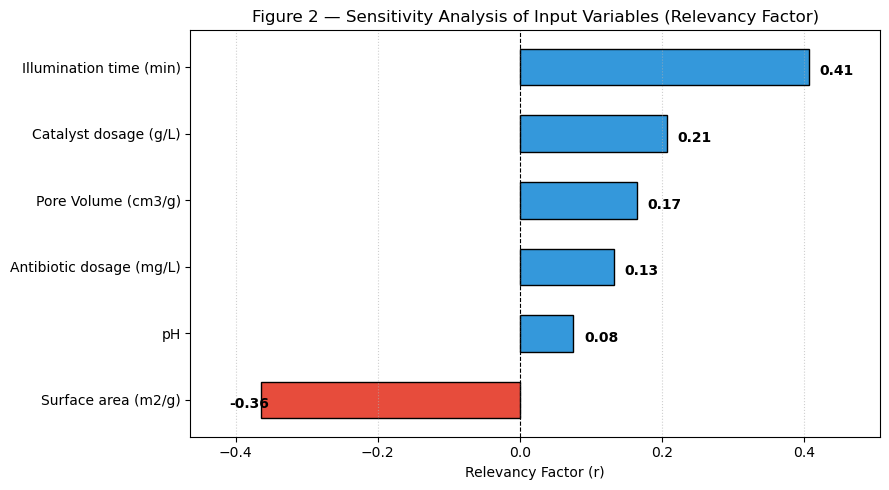

In [17]:
# SENSITIVITY ANALYSIS
def compute_relevancy_factor(X_df: pd.DataFrame, y_sr: pd.Series) -> pd.Series:
    """Eq. (24): Pearson correlation-based Relevancy Factor (r) for each input."""
    X_mean = X_df.mean()
    y_mean = y_sr.mean()

    numerator = ((X_df - X_mean).multiply(y_sr - y_mean, axis=0)).sum()
    denominator = np.sqrt(((X_df - X_mean) ** 2).sum() * np.sum((y_sr - y_mean) ** 2))
    return numerator / denominator

relevancy_scores = compute_relevancy_factor(X, y).sort_values()

plt.figure(figsize=(9, 5))
colors = ["#e74c3c" if val < 0 else "#3498db" for val in relevancy_scores.values]
bars = plt.barh(relevancy_scores.index, relevancy_scores.values, color=colors, edgecolor="black", height=0.55)
plt.axvline(0, color="black", linestyle="--", lw=0.8)

for bar in bars:
    w = bar.get_width()
    offset = 0.015 if w >= 0 else -0.045
    plt.text(w + offset, bar.get_y() + 0.15, f"{w:.2f}", fontsize=10, fontweight="bold")

plt.title("Figure 2 — Sensitivity Analysis of Input Variables (Relevancy Factor)", fontsize=12)
plt.xlabel("Relevancy Factor (r)")
plt.xlim(min(relevancy_scores.values) - 0.1, max(relevancy_scores.values) + 0.1)
plt.grid(True, axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

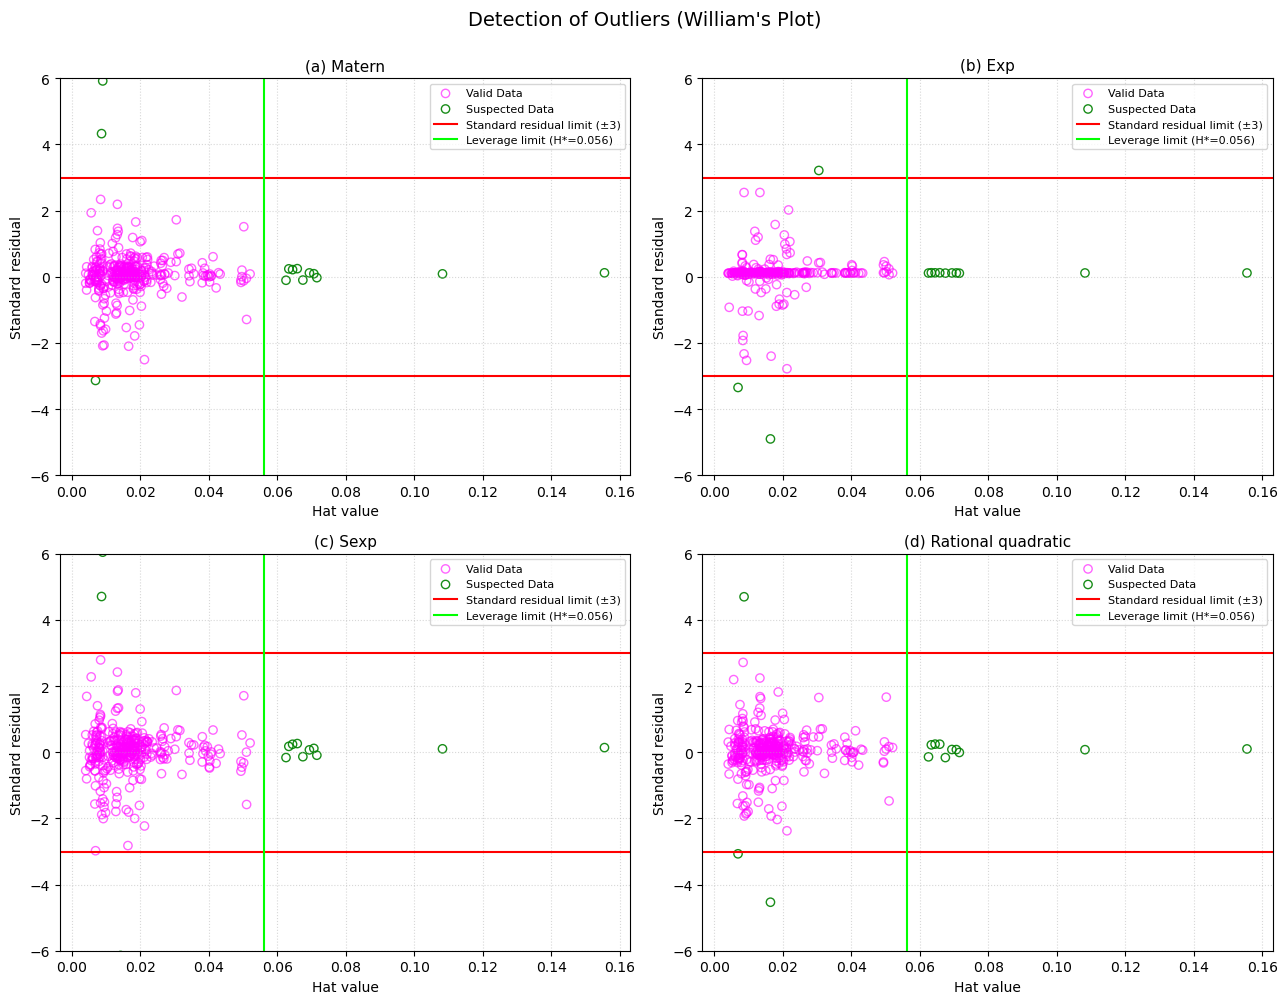

In [18]:
# LEVERAGE OUTLIER DETECTION: WILLIAM'S PLOT
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# Hat matrix Leverage threshold
n_samples, n_params = X.shape[0], X.shape[1]
h_star = 3.0 * (n_params + 1) / n_samples

X_mat = np.column_stack([np.ones(n_samples), StandardScaler().fit_transform(X)])
H = X_mat @ np.linalg.pinv(X_mat.T @ X_mat) @ X_mat.T
hat_values = np.diag(H)

for idx, (model_name, model_pipe) in enumerate(fitted_models.items()):
    ax = axes[idx]
    y_pred_all = model_pipe.predict(X)
    residuals = y.values - y_pred_all
    std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

    # Classify valid vs suspected
    is_outlier = (np.abs(std_residuals) > 3) | (hat_values > h_star)
    
    ax.scatter(hat_values[~is_outlier], std_residuals[~is_outlier], 
               facecolors="none", edgecolors="magenta", label="Valid Data", alpha=0.6)
    ax.scatter(hat_values[is_outlier], std_residuals[is_outlier], 
               facecolors="none", edgecolors="green", label="Suspected Data", alpha=0.9)

    ax.axhline(3, color="red", linestyle="-", lw=1.5, label="Standard residual limit (±3)")
    ax.axhline(-3, color="red", linestyle="-", lw=1.5)
    ax.axvline(h_star, color="lime", linestyle="-", lw=1.5, label=f"Leverage limit (H*={h_star:.3f})")

    ax.set_title(f"({chr(97 + idx)}) {model_name.replace('GPR ', '').capitalize()}", fontsize=11)
    ax.set_xlabel("Hat value")
    ax.set_ylabel("Standard residual")
    ax.set_ylim(-6, 6)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Detection of Outliers (William's Plot)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

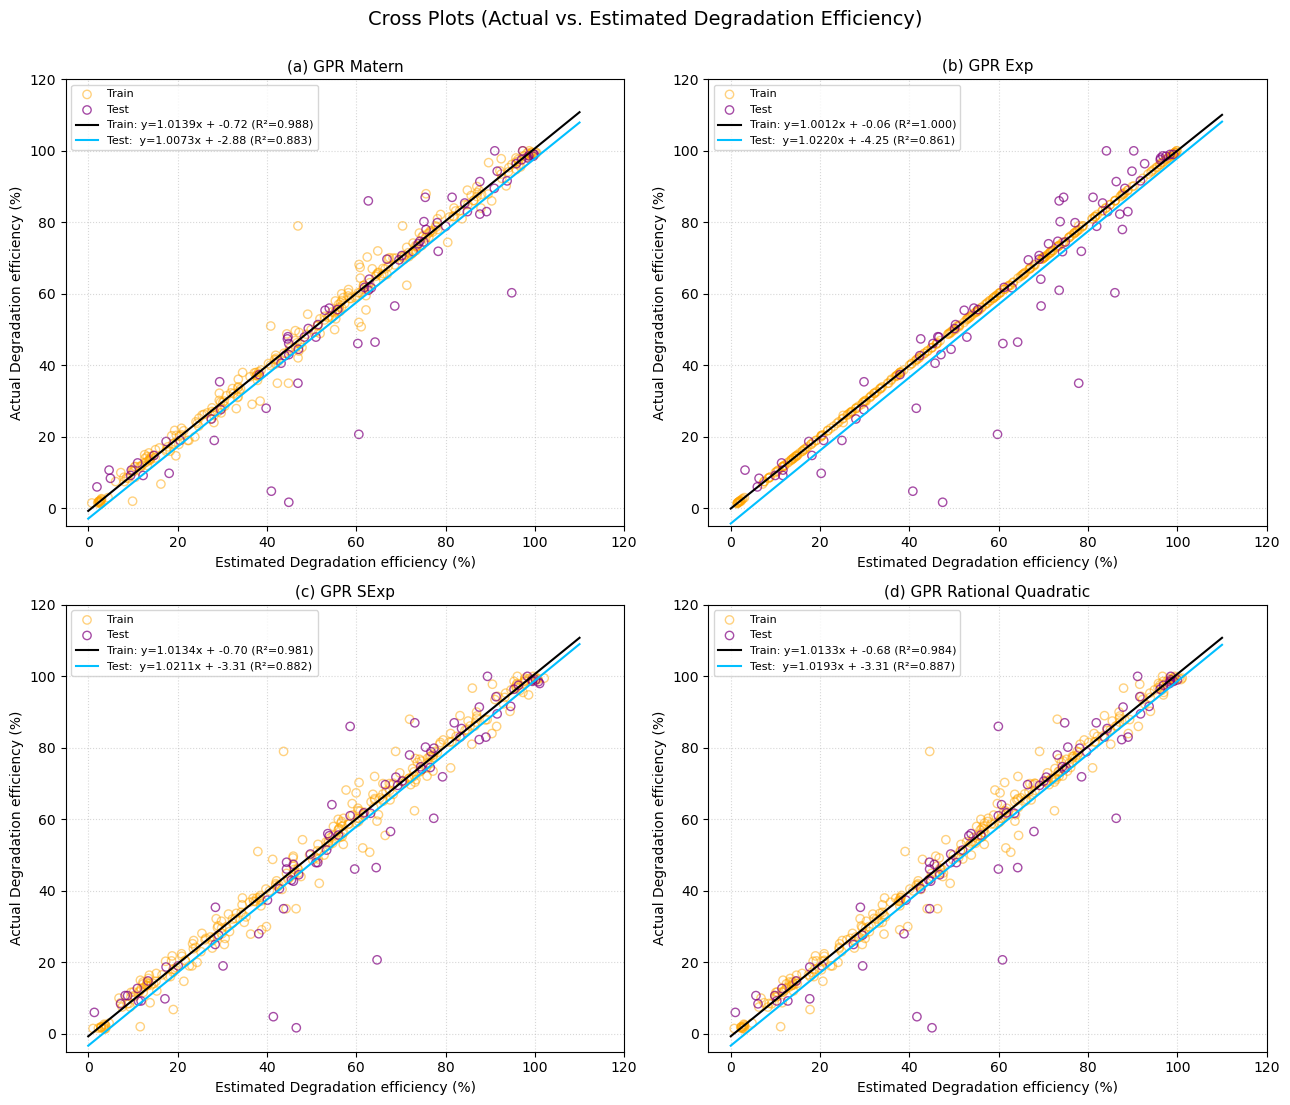

In [19]:
# CROSS-PLOTS & LINEAR REGRESSION FITS
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for idx, (model_name, model_pipe) in enumerate(fitted_models.items()):
    ax = axes[idx]
    
    # Train fit line
    y_tr_pred = model_pipe.predict(X_train)
    slope_tr, intercept_tr, r_val_tr, _, _ = stats.linregress(y_tr_pred, y_train)
    
    # Test fit line
    y_te_pred = model_pipe.predict(X_test)
    slope_te, intercept_te, r_val_te, _, _ = stats.linregress(y_te_pred, y_test)

    ax.scatter(y_tr_pred, y_train, facecolors="none", edgecolors="orange", alpha=0.5, label="Train")
    ax.scatter(y_te_pred, y_test, facecolors="none", edgecolors="purple", alpha=0.7, label="Test")

    x_domain = np.linspace(0, 110, 100)
    ax.plot(x_domain, slope_tr * x_domain + intercept_tr, color="black", lw=1.5, 
            label=f"Train: y={slope_tr:.4f}x + {intercept_tr:.2f} (R²={r_val_tr**2:.3f})")
    ax.plot(x_domain, slope_te * x_domain + intercept_te, color="deepskyblue", lw=1.5, 
            label=f"Test:  y={slope_te:.4f}x + {intercept_te:.2f} (R²={r_val_te**2:.3f})")

    ax.set_title(f"({chr(97 + idx)}) {model_name}", fontsize=11)
    ax.set_xlabel("Estimated Degradation efficiency (%)")
    ax.set_ylabel("Actual Degradation efficiency (%)")
    ax.set_xlim(-5, 120)
    ax.set_ylim(-5, 120)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Cross Plots (Actual vs. Estimated Degradation Efficiency)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

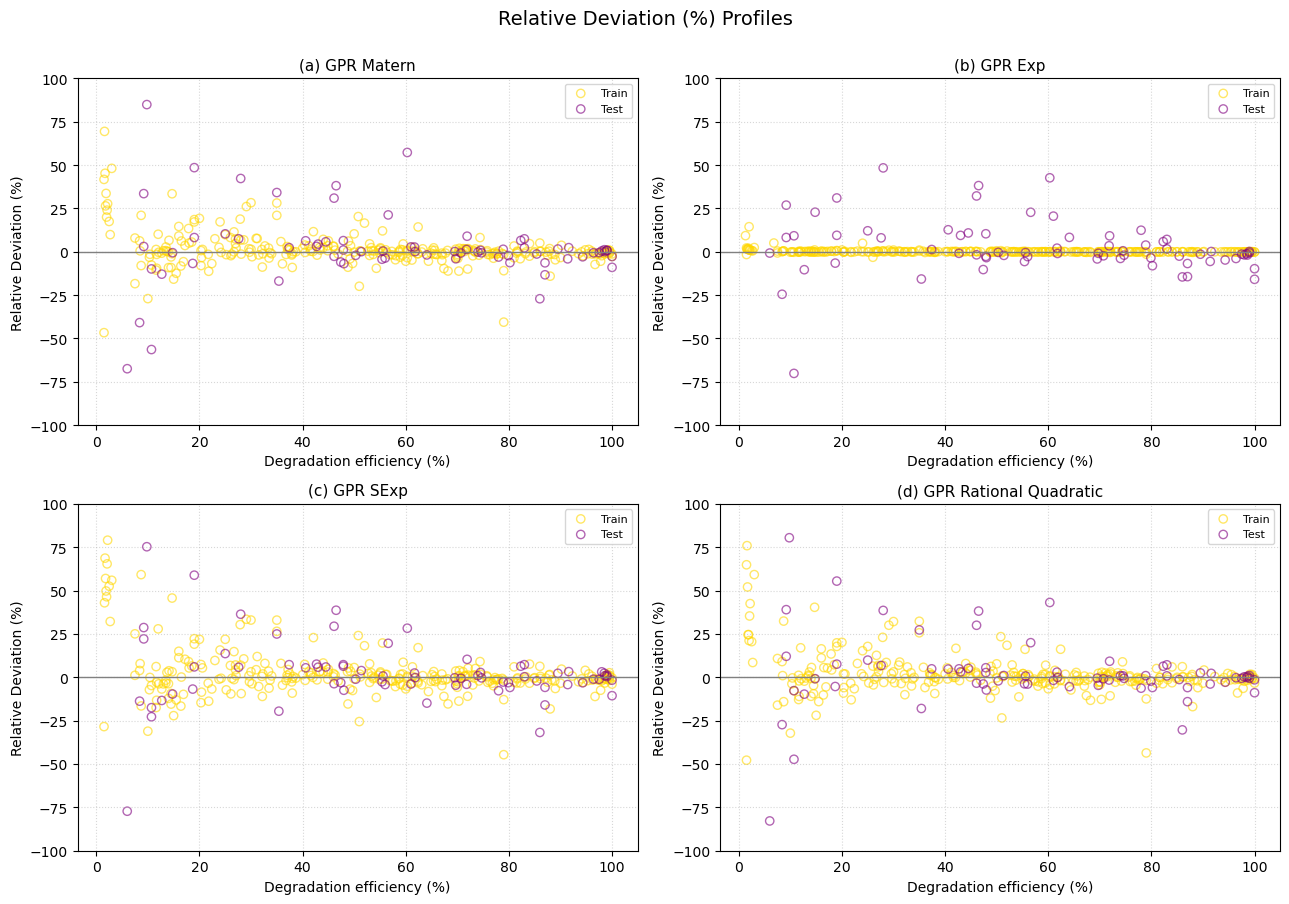

In [20]:
# RELATIVE DEVIATION PROFILES
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for idx, (model_name, model_pipe) in enumerate(fitted_models.items()):
    ax = axes[idx]
    
    y_tr_pred = model_pipe.predict(X_train)
    y_te_pred = model_pipe.predict(X_test)
    
    dev_tr = ((y_tr_pred - y_train.values) / np.where(y_train.values == 0, 1e-6, y_train.values)) * 100
    dev_te = ((y_te_pred - y_test.values) / np.where(y_test.values == 0, 1e-6, y_test.values)) * 100

    ax.scatter(y_train, dev_tr, facecolors="none", edgecolors="gold", alpha=0.6, label="Train")
    ax.scatter(y_test, dev_te, facecolors="none", edgecolors="purple", alpha=0.6, label="Test")
    ax.axhline(0, color="gray", lw=1)

    ax.set_title(f"({chr(97 + idx)}) {model_name}", fontsize=11)
    ax.set_xlabel("Degradation efficiency (%)")
    ax.set_ylabel("Relative Deviation (%)")
    ax.set_ylim(-100, 100)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Relative Deviation (%) Profiles", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()